# Scattering theory and photon-detection cross sections

A **cross section** $\sigma$ is the effective target area a particle presents: the scattered rate divided
by the incident flux. It is the quantity that decides whether a photon is detected -- the absorption cross
section sets a detector's attenuation length and quantum efficiency. This notebook develops quantum
scattering theory (Griffiths Ch. 11) and connects it to photon detection, verifying each result
numerically:

- **Partial waves and phase shifts** -- $\sigma=\dfrac{4\pi}{k^2}\sum_l(2l+1)\sin^2\delta_l$; the hard
  sphere gives the famous low-energy $\sigma\to4\pi a^2$ (four times geometric).
- **Born approximation** -- the amplitude is the **Fourier transform of the potential**,
  $f(\theta)\propto\int e^{i\mathbf q\cdot\mathbf r}V\,d^3r$. For a Yukawa potential this is the Lorentzian
  $1/(q^2+\mu^2)$ -- the *same* propagator as the virtual photon (Feynman notebook) -- and its Coulomb
  limit is **Rutherford** $d\sigma/d\Omega\propto1/\sin^4(\theta/2)$.
- **Optical theorem** -- $\sigma_{\text{tot}}=\dfrac{4\pi}{k}\,\mathrm{Im}\,f(0)$, an exact consequence of
  probability conservation (unitarity) -- the conservation-laws thread again.
- **Photon detection** -- the Thomson cross section $\sigma_T=\tfrac{8\pi}{3}r_e^2$ of a free electron, and
  **Beer-Lambert** attenuation $I=I_0e^{-n\sigma L}$ that fixes detector thickness for a target quantum
  efficiency; the absorption cross section is the golden-rule rate per unit incident flux.

Self-contained: NumPy, SymPy, Pandas, Matplotlib (plus `scipy.special` for spherical Bessel functions).

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## Partial waves and the hard-sphere cross section

For a central potential the amplitude is $f(\theta)=\dfrac1k\sum_l(2l+1)e^{i\delta_l}\sin\delta_l
P_l(\cos\theta)$ and the total cross section is $\sigma=\dfrac{4\pi}{k^2}\sum_l(2l+1)\sin^2\delta_l$. A
**hard sphere** of radius $a$ imposes $u_l(a)=0$, giving $\delta_l=\arctan\!\big[j_l(ka)/n_l(ka)\big]$; in
particular $\delta_0=-ka$ exactly. At low energy only the $l=0$ wave survives and
$\sigma\to4\pi a^2$ -- four times the geometric $\pi a^2$, a purely quantum (diffractive) result. At high
energy $\sigma\to2\pi a^2$.

In [2]:
from scipy.special import spherical_jn, spherical_yn
a = 1.0
def phase_shifts(k, lmax):
    l = np.arange(lmax + 1); x = k*a
    return np.arctan(spherical_jn(l, x) / spherical_yn(l, x))     # delta_l for a hard sphere
def sigma_total(k, lmax=None):
    if lmax is None: lmax = int(k*a) + 12
    l = np.arange(lmax + 1); dl = phase_shifts(k, lmax)
    return (4*np.pi/k**2) * np.sum((2*l + 1) * np.sin(dl)**2)

# delta_0 = -ka exactly
k = 0.3
assert abs(phase_shifts(k, 0)[0] - (-k*a)) < 1e-9
# low-energy total cross section -> 4 pi a^2
sig_low = sigma_total(0.02)
print(f"low-energy sigma = {sig_low:.4f}   4 pi a^2 = {4*np.pi*a**2:.4f}   (ratio {sig_low/(4*np.pi*a**2):.4f})")
assert abs(sig_low - 4*np.pi*a**2) < 0.02*4*np.pi*a**2
# high-energy approaches 2 pi a^2
print(f"high-energy sigma(k=8) = {sigma_total(8.0):.3f}   2 pi a^2 = {2*np.pi*a**2:.3f}")

low-energy sigma = 12.5647   4 pi a^2 = 12.5664   (ratio 0.9999)
high-energy sigma(k=8) = 7.713   2 pi a^2 = 6.283


## Born approximation: the amplitude is the Fourier transform of the potential

For a weak potential, $f_{\text{Born}}(\theta)=-\dfrac{2m}{\hbar^2 q}\displaystyle\int_0^\infty rV(r)\sin(qr)\,dr$
with momentum transfer $q=2k\sin(\theta/2)$. For the **Yukawa** potential $V=\beta e^{-\mu r}/r$ this
integrates to
$$f_{\text{Born}}=-\frac{2m\beta}{\hbar^2}\,\frac{1}{\mu^2+q^2},$$
the **same Lorentzian $1/(q^2+\mu^2)$** as the virtual-photon propagator. We confirm the closed form against
numerical integration, then take $\mu\to0$ (Coulomb) to recover **Rutherford**
$d\sigma/d\Omega=|f|^2\propto1/q^4\propto1/\sin^4(\theta/2)$.

In [3]:
def f_born_numeric(q, beta=1.0, mu=1.0, m=1.0, hbar=1.0, rmax=80.0, n=400000):
    r = np.linspace(1e-7, rmax, n)
    return -(2*m/(hbar**2*q)) * np.trapezoid(r*(beta*np.exp(-mu*r)/r)*np.sin(q*r), r)
f_born_closed = lambda q, beta=1.0, mu=1.0, m=1.0, hbar=1.0: -(2*m*beta/hbar**2)/(mu**2 + q**2)

k = 2.0
for th_deg in (30, 60, 90, 150):
    q = 2*k*np.sin(np.radians(th_deg)/2)
    assert abs(f_born_numeric(q) - f_born_closed(q)) < 1e-3      # numeric = Lorentzian 1/(mu^2+q^2)
print("Born Yukawa amplitude = -(2m beta/hbar^2)/(mu^2+q^2)  (verified vs numerical FT)")
print("=> same 1/(q^2+mu^2) as the virtual-photon propagator (Feynman notebook)")

# Rutherford (Coulomb) limit mu->0: dsigma/dOmega ~ 1/sin^4(theta/2)
mu0 = 1e-6
th = np.radians(np.array([30., 60., 90., 120.]))
q = 2*k*np.sin(th/2)
dsig = np.abs([f_born_closed(qi, mu=mu0) for qi in q])**2
ratio = dsig/dsig[-1]
rutherford = (np.sin(th[-1]/2)/np.sin(th/2))**4
assert np.allclose(ratio, rutherford, rtol=1e-3)                 # 1/q^4 == 1/sin^4(theta/2)
print("Coulomb limit reproduces Rutherford 1/sin^4(theta/2):", np.allclose(ratio, rutherford, rtol=1e-3))

Born Yukawa amplitude = -(2m beta/hbar^2)/(mu^2+q^2)  (verified vs numerical FT)
=> same 1/(q^2+mu^2) as the virtual-photon propagator (Feynman notebook)
Coulomb limit reproduces Rutherford 1/sin^4(theta/2): True


## The optical theorem: forward scattering measures the total cross section

Probability conservation (unitarity of the scattering matrix) forces
$$\sigma_{\text{tot}}=\frac{4\pi}{k}\,\mathrm{Im}\,f(0).$$
The imaginary part of the *forward* amplitude accounts for all flux removed from the beam -- exactly what a
transmission (attenuation) measurement records. From the partial-wave sum, $\mathrm{Im}\,f(0)=\tfrac1k\sum
(2l+1)\sin^2\delta_l$, so $\tfrac{4\pi}{k}\mathrm{Im}\,f(0)$ equals the $\sigma$ computed above -- verified
to machine precision for the hard sphere.

In [4]:
def f_forward(k, lmax=None):
    if lmax is None: lmax = int(k*a) + 12
    l = np.arange(lmax + 1); dl = phase_shifts(k, lmax)
    return (1/k) * np.sum((2*l + 1) * np.exp(1j*dl) * np.sin(dl))   # f(0): P_l(1)=1

for k in (0.5, 2.0, 5.0):
    sig = sigma_total(k)
    sig_opt = (4*np.pi/k) * f_forward(k).imag
    print(f"k={k}:  sigma = {sig:.6f}   (4 pi/k) Im f(0) = {sig_opt:.6f}   match {np.isclose(sig, sig_opt)}")
    assert np.isclose(sig, sig_opt)                               # optical theorem (unitarity/conservation)

k=0.5:  sigma = 11.752760   (4 pi/k) Im f(0) = 11.752760   match True
k=2.0:  sigma = 9.421911   (4 pi/k) Im f(0) = 9.421911   match True
k=5.0:  sigma = 8.175607   (4 pi/k) Im f(0) = 8.175607   match True


## Photon-detection cross sections

**Thomson scattering.** A free electron scatters light with cross section $\sigma_T=\tfrac{8\pi}{3}r_e^2$,
$r_e=\dfrac{e^2}{4\pi\varepsilon_0 m_ec^2}$ the classical electron radius -- the fundamental photon-electron
cross section, $6.65\times10^{-29}\,\mathrm{m}^2$. **Rayleigh** scattering of bound electrons scales as
$\omega^4$ (why the sky is blue). **Detection.** An absorption cross section $\sigma$ gives Beer-Lambert
attenuation $I=I_0e^{-n\sigma L}$, so the quantum efficiency of a detector of thickness $L$ is
$\eta=1-e^{-n\sigma L}$; the absorption cross section is itself the golden-rule transition rate per unit
incident photon flux (golden-rule notebook).

In [5]:
r_e = C.E**2/(4*np.pi*C.EPS0*C.M_E*C.C**2)
sigma_T = (8*np.pi/3)*r_e**2
print(f"classical electron radius r_e = {r_e:.4e} m")
print(f"Thomson cross section sigma_T = {sigma_T:.4e} m^2  (= 0.665 barn)")
assert abs(r_e - 2.818e-15) < 1e-17 and abs(sigma_T - 6.652e-29) < 1e-31

# Rayleigh omega^4: blue scatters far more than red -> blue sky
ratio_blue_red = (650/450)**4
print(f"Rayleigh sigma(450nm)/sigma(650nm) = (650/450)^4 = {ratio_blue_red:.2f}  -> sky is blue")

# Beer-Lambert quantum efficiency of a photodetector
n_density = 5e28          # absorbers per m^3 (solid-density)
sigma_abs = 1e-22         # m^2, representative photoabsorption cross section
mu_att = n_density*sigma_abs                       # attenuation coefficient, 1/m
pen_depth = 1/mu_att                               # 1/e penetration depth
QE = lambda L: 1 - np.exp(-mu_att*L)
L90 = -np.log(1 - 0.90)/mu_att
rows = [{"thickness L [um]": round(L*1e6, 2), "quantum efficiency": round(QE(L), 3)}
        for L in (pen_depth, 2*pen_depth, L90, 3*L90)]
print(f"\nattenuation coeff n*sigma = {mu_att:.1f} /m,  penetration depth = {pen_depth*1e6:.2f} um")
print(pd.DataFrame(rows).to_string(index=False))
print(f"thickness for 90% QE = {L90*1e6:.2f} um")
assert abs(QE(L90) - 0.90) < 1e-9

classical electron radius r_e = 2.8179e-15 m
Thomson cross section sigma_T = 6.6525e-29 m^2  (= 0.665 barn)
Rayleigh sigma(450nm)/sigma(650nm) = (650/450)^4 = 4.35  -> sky is blue

attenuation coeff n*sigma = 5000000.0 /m,  penetration depth = 0.20 um
 thickness L [um]  quantum efficiency
             0.20               0.632
             0.40               0.865
             0.46               0.900
             1.38               0.999
thickness for 90% QE = 0.46 um


## Plots

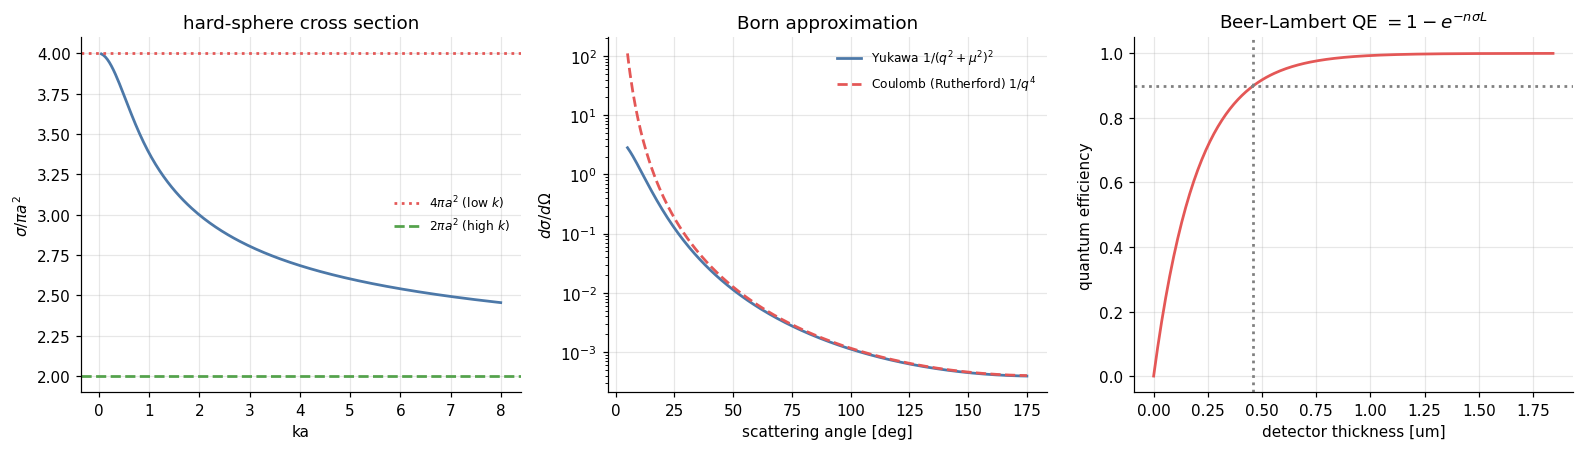

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
# (1) hard-sphere total cross section: 4 pi a^2 (low k) -> 2 pi a^2 (high k)
ks = np.linspace(0.05, 8, 200)
sig = np.array([sigma_total(k) for k in ks])
ax[0].plot(ks, sig/(np.pi*a**2), color="#4C78A8")
ax[0].axhline(4, ls=":", color="#E45756", label=r"$4\pi a^2$ (low $k$)")
ax[0].axhline(2, ls="--", color="#54A24B", label=r"$2\pi a^2$ (high $k$)")
ax[0].set_xlabel("ka"); ax[0].set_ylabel(r"$\sigma/\pi a^2$")
ax[0].set_title("hard-sphere cross section"); ax[0].legend(fontsize=8)
# (2) Born: Yukawa vs Rutherford differential cross section (forward peak)
thg = np.radians(np.linspace(5, 175, 300)); qg = 2*k*np.sin(thg/2)
ax[1].semilogy(np.degrees(thg), np.abs([f_born_closed(q, mu=1.0) for q in qg])**2,
               color="#4C78A8", label=r"Yukawa $1/(q^2+\mu^2)^2$")
ax[1].semilogy(np.degrees(thg), np.abs([f_born_closed(q, mu=1e-6) for q in qg])**2,
               "--", color="#E45756", label=r"Coulomb (Rutherford) $1/q^4$")
ax[1].set_xlabel("scattering angle [deg]"); ax[1].set_ylabel(r"$d\sigma/d\Omega$")
ax[1].set_title("Born approximation"); ax[1].legend(fontsize=8)
# (3) Beer-Lambert detector quantum efficiency vs thickness
Ls = np.linspace(0, 4*L90, 200)
ax[2].plot(Ls*1e6, QE(Ls), color="#E45756")
ax[2].axhline(0.9, ls=":", color="gray"); ax[2].axvline(L90*1e6, ls=":", color="gray")
ax[2].set_xlabel("detector thickness [um]"); ax[2].set_ylabel("quantum efficiency")
ax[2].set_title(r"Beer-Lambert QE $=1-e^{-n\sigma L}$")
plt.tight_layout(); plt.show()

## Exercises

1. **Ramsauer-Townsend.** For an attractive square well, find the energy where $\delta_0=\pi$ so
   $\sigma\to0$ -- the transparency that makes noble gases nearly collisionless to slow electrons.
2. **Resonance.** Show a rapid rise of $\delta_l$ through $\pi/2$ produces a Breit-Wigner peak in
   $\sigma_l$; relate its width to a lifetime (golden-rule notebook).
3. **Klein-Nishina.** Beyond Thomson, the Compton cross section falls with photon energy; plot the
   Klein-Nishina $\sigma(E_\gamma)$ and find where it drops to $\tfrac12\sigma_T$.
4. **Detector design.** For a silicon photodiode ($\sigma_{\text{abs}}$, $n$ from its density) compute the
   depletion thickness for 95% quantum efficiency at 850 nm, and compare with a thin 2D material.

## Summary

- The cross section $\sigma$ is the scattered-rate-per-incident-flux; **partial waves** give
  $\sigma=\tfrac{4\pi}{k^2}\sum(2l+1)\sin^2\delta_l$, with the hard sphere's low-energy $4\pi a^2$ verified.
- The **Born** amplitude is the Fourier transform of the potential; the Yukawa case is the Lorentzian
  $1/(q^2+\mu^2)$ (the virtual-photon propagator), and its Coulomb limit is **Rutherford**
  $1/\sin^4(\theta/2)$ (verified).
- The **optical theorem** $\sigma_{\text{tot}}=\tfrac{4\pi}{k}\mathrm{Im}f(0)$ follows from unitarity and is
  confirmed to machine precision -- forward scattering measures total attenuation.
- **Photon detection**: $\sigma_T=\tfrac{8\pi}{3}r_e^2=6.65\times10^{-29}\,\mathrm{m}^2$; Rayleigh's
  $\omega^4$ blues the sky; and **Beer-Lambert** $\eta=1-e^{-n\sigma L}$ sets detector thickness for a
  target quantum efficiency.

Subject-verb-object: the potential scatters the wave; the phase shifts sum to a cross section; the optical
theorem conserves flux; the absorption cross section detects the photon.